In [2]:
import numpy as np
import matplotlib.pyplot as plt
def wrap_to_pi(angle):
    return (angle + np.pi) % (2*np.pi) - np.pi

In [4]:
import numpy as np

# Función auxiliar para que no te dé error el ángulo (por si no la tenías)
def wrap_to_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

def simulate_unicycle(x0, goal, k_rho=0.8, k_alpha=2.0, dt=0.02, T=20.0, v_max=1.5, w_max=2.5):
    """
    x0 = [x, y, theta] estado inicial
    goal = [xg, yg] objetivo
    Control go-to-goal: v = k_rho * rho, w = k_alpha * alpha
    """
    steps = int(T / dt)
    xs = np.zeros((steps, 3))
    xs[0] = x0
    xg, yg = goal
    
    for k in range(steps-1):
        x, y, th = xs[k]
        ex, ey = xg - x, yg - y
        
        rho = np.hypot(ex, ey) # distancia al objetivo
        alpha = wrap_to_pi(np.arctan2(ey, ex) - th) # ángulo hacia el objetivo relativo al heading
        
        v = k_rho * rho
        w = k_alpha * alpha
        
        # Saturaciones
        v = np.clip(v, -v_max, v_max)
        w = np.clip(w, -w_max, w_max)
        
        # Dinámica uniciclo
        x_dot = v * np.cos(th)
        y_dot = v * np.sin(th)
        th_dot = w
        
        # Integración de Euler
        xs[k+1, 0] = x + dt * x_dot
        xs[k+1, 1] = y + dt * y_dot
        xs[k+1, 2] = wrap_to_pi(th + dt * th_dot)
        
        # Parar si ya llegó cerca
        if rho < 0.02:
            xs[(k+1):] = xs[k+1]
            break
            
    t = np.arange(steps) * dt
    return t, xs


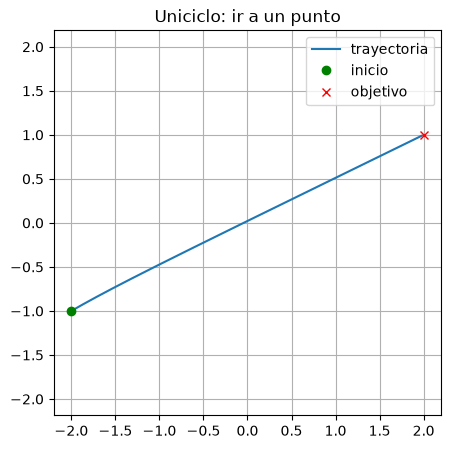

In [5]:
x0 = np.array([ -2.0, -1.0, np.deg2rad(30.0) ]) # estado inicial
goal = np.array([ 2.0, 1.0 ]) # objetivo
t, xs = simulate_unicycle(x0, goal, k_rho=0.9, k_alpha=3.0, dt=0.02, T=15.0)
plt.figure(figsize=(5,5))
plt.plot(xs[:,0], xs[:,1], label='trayectoria')
plt.plot([x0[0]], [x0[1]], 'go', label='inicio')
plt.plot([goal[0]], [goal[1]], 'rx', label='objetivo')
plt.axis('equal'); plt.grid(True); plt.legend(); plt.title('Uniciclo: ir a un punto')
plt.show()

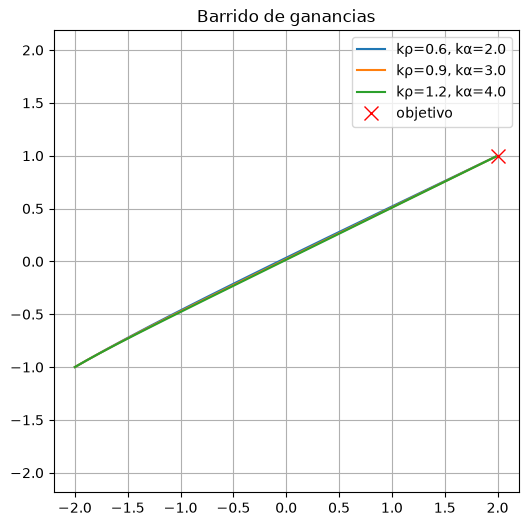

In [7]:
ks = [(0.6, 2.0), (0.9, 3.0), (1.2, 4.0)]
plt.figure(figsize=(6,6))

# El ciclo FOR necesita 4 espacios de indentación
for k_rho, k_alpha in ks:
    _, xs = simulate_unicycle(x0, goal, k_rho=k_rho, k_alpha=k_alpha, T=12.0)
    plt.plot(xs[:,0], xs[:,1], label=f'kρ={k_rho}, kα={k_alpha}')

# Esto va FUERA del ciclo (alineado a la izquierda) para que se dibuje una sola vez
plt.plot([goal[0]], [goal[1]], 'rx', markersize=10, label='objetivo')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title('Barrido de ganancias')
plt.show()